# **Libraries**

In [10]:
import json # for reading json files
import re # for tweets cleaning
from wordcloud import WordCloud, STOPWORDS # for wordclound
import matplotlib.pyplot as plt # for ploting

# **Loading Dataset**

In [5]:
with open('/content/CETM47-23_24-AS2-Data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
print(type(data))
print(data[0])

<class 'list'>
{'text': 'The {@Clinton LumberKings@} beat the {@Cedar Rapids Kernels@} 4-0 in Game 1 of the Western Division finals. Evan Edwards hit a 2-run HR. WP Josh Roberson: 5 IP, 3 H, 0 R, 0 BB, 10 K #MWLplayoffs #MWLscoreboard', 'date': '2019-09-08', 'label': 4, 'id': 1170516324419866624, 'label_name': 'sports_&_gaming'}


# **Extracting All tweets**

In [13]:
good_tweets = []
bad_tweets = []

for item in data:
    if item['label'] in [4, 5]:
        good_tweets.append(item['text'])
    elif item['label'] in [0, 1]:
        bad_tweets.append(item['text'])

print("Good tweets:", len(good_tweets))
print("Bad tweets:", len(bad_tweets))

Good tweets: 2617
Bad tweets: 431


# Cleaning All **Tweets**

In [14]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

good_cleaned = " ".join([clean_text(t) for t in good_tweets])
bad_cleaned = " ".join([clean_text(t) for t in bad_tweets])

print(good_cleaned[:300])
print("-----")
print(bad_cleaned[:300])

the  lumberkings beat the  rapids kernels  in game  of the western division finals evan edwards hit a run hr wp josh roberson  ip  h  r  bb  k mwlplayoffs mwlscoreboard i would rather hear eli gold announce this auburn game than these dumbasses  someone take my phone away im trying to not look at  b
-----
vanillalace vs dupe with pink himalayan sea salt argan hemp organic handmade luxury soap cakes bestselling vegan soapas mothers day soap url via  great to see another aussie worldleading business stepping up on the issues that will define our future  cannon brookes  on climate change its up to all o


# **Create the Word Cloud**

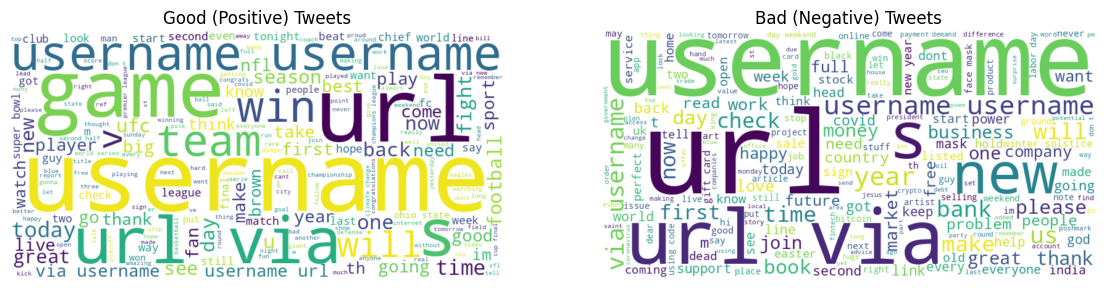

In [15]:
stopwords = set(STOPWORDS)
stopwords.update(["rt"])

# Create word clouds
good_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords
).generate(good_cleaned)

bad_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords
).generate(bad_cleaned)

# Plot side by side
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(good_wc, interpolation="bilinear")
plt.title("Good (Positive) Tweets")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bad_wc, interpolation="bilinear")
plt.title("Bad (Negative) Tweets")
plt.axis("off")

plt.show()